In [262]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import math
import seaborn as sns
from scipy import stats

In [263]:
data = pd.read_csv('data/Concrete_Data.csv')
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


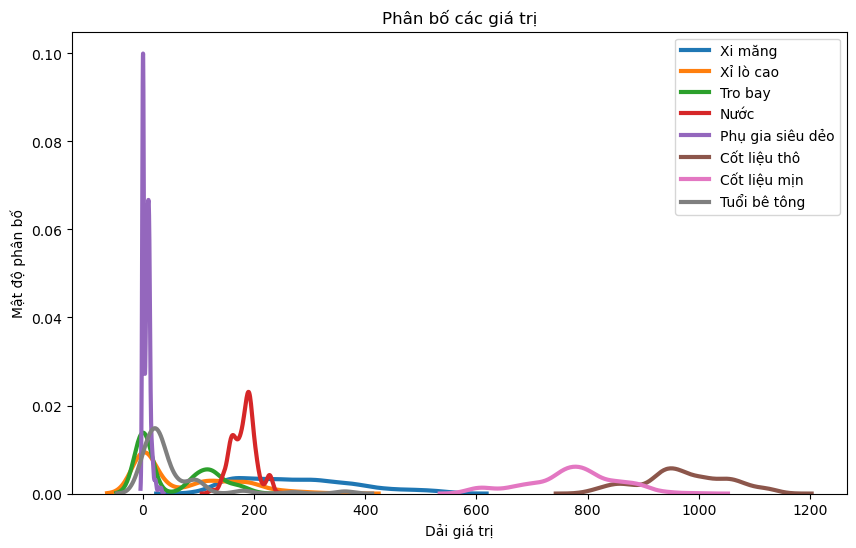

In [264]:
vn_columns = [
    "Xi măng",
    "Xỉ lò cao",
    "Tro bay",
    "Nước",
    "Phụ gia siêu dẻo",
    "Cốt liệu thô",
    "Cốt liệu mịn",
    "Tuổi bê tông",
    "Cường độ chịu nén của bê tông"
]
plt.figure(figsize=(10, 6))

for i in range(data.shape[1] - 1):
    sns.kdeplot(data.iloc[:, i], label=vn_columns[i], linewidth=3)

plt.title('Phân bố các giá trị')
plt.xlabel('Dải giá trị')
plt.ylabel('Mật độ phân bố')
plt.legend()
plt.show()

In [265]:
data.iloc[:, :-1].describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000


In [266]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [267]:
z_scores = np.abs(stats.zscore(X_train, axis=0))
mask = (z_scores < 3).all(axis=1)
X_train = X_train[mask]
y_train = y_train[mask]

In [268]:
# for i in range(X_train.shape[1] - 1):

#     Q1 = data.iloc[:, i].quantile(0.25)
#     Q3 = data.iloc[:, i].quantile(0.75)
#     IQR = Q3 - Q1
#     low_threshold = Q1 - 1.5*IQR
#     up_threshold = Q3 + 1.5*IQR

#     X_train = X_train[(X_train.iloc[:, i] >= low_threshold) & (X_train.iloc[:, i] <= up_threshold)]

# X_train.describe()

In [269]:
def polynomial_features(X, num_col, d):
    n = X.shape[0]
    converted_X = np.zeros(shape=(n, d))

    converted_X[:, 0] = np.ones(n)

    for i in range(n):
        k = 1
        for j in range(num_col):
            converted_X[i, k] = X[i, j]
            k += 1

            converted_X[i, k] = X[i, j] ** 2
            k += 1
            for m in range(j + 1, num_col):
                converted_X[i, k] = X[i, j] * X[i, m]
                k += 1

            converted_X[i, k] = X[i, j] ** 3
            k += 1
            for m in range(j + 1, num_col):
                converted_X[i, k] = X[i, j] ** 2 * X[i, m]
                k += 1
                converted_X[i, k] = X[i, j] * X[i, m] ** 2
                k += 1
                for l in range(m + 1, num_col):
                    converted_X[i, k] = X[i, j] * X[i, m] * X[i, l]
                    k += 1
    return converted_X

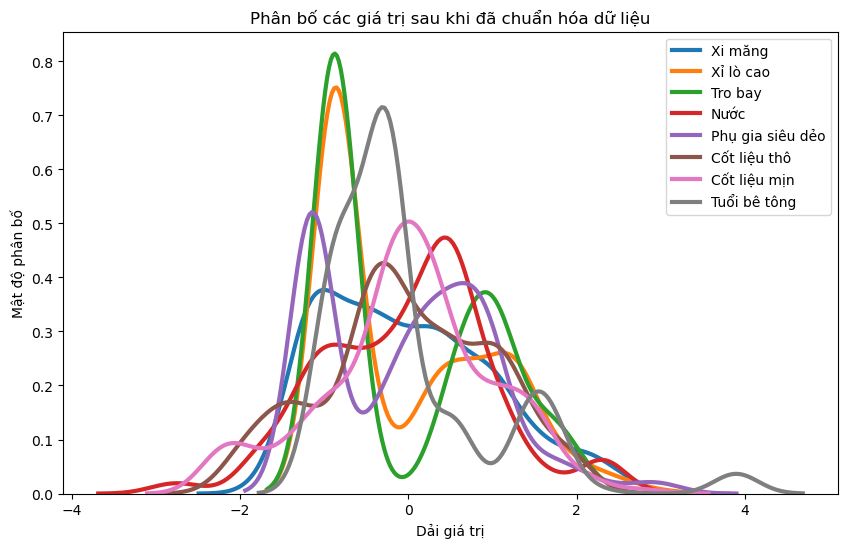

In [270]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(10, 6))

for i in range(X_train.shape[1]):
    sns.kdeplot(X_train[:, i], label=vn_columns[i], linewidth=3)

# sns.kdeplot(y_train, label=vn_columns[-1], linewidth=3)

plt.title('Phân bố các giá trị sau khi đã chuẩn hóa dữ liệu')
plt.xlabel('Dải giá trị')
plt.ylabel('Mật độ phân bố')
plt.legend()
plt.show()

In [271]:
y_test = y_test.values
y_train = y_train.values

num_col = X.shape[1]
d = 1 + (num_col) + (num_col + math.comb(num_col, 2) ) + (num_col + 2 * math.comb(num_col, 2) + math.comb(num_col, 3))


In [272]:
X_train = polynomial_features(X_train, num_col, d)
X_test = polynomial_features(X_test, num_col, d)

In [273]:
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])

In [ ]:

eta   = 0.0001
theta = 0.000001
w = np.zeros(shape=(d, 1))
n = X_train.shape[0]
k = 1
max_k = 50000000
while True:
    for i in range(n):
        etaTemp = eta / (k / 100000 + 1)
        k += 1
        deltaJ = (X_train[i] @ w - y_train[i]) * X_train[i].reshape(-1, 1)
        w = w - etaTemp * deltaJ
        if etaTemp * np.linalg.norm(deltaJ) < theta:
            break
    if k == max_k:
        break
            
print(k)


50000000


In [275]:
print('Tổng số mẫu: ', X.shape[0])
print('Số mẫu training: ', X_train.shape[0])
print('Số mẫu testing: ', X_test.shape[0])

Tổng số mẫu:  1030
Số mẫu training:  788
Số mẫu testing:  206


In [276]:
y_pred = X_test @ w
mse = mean_squared_error(y_pred, y_test)
print(mse)

475.13623394323054


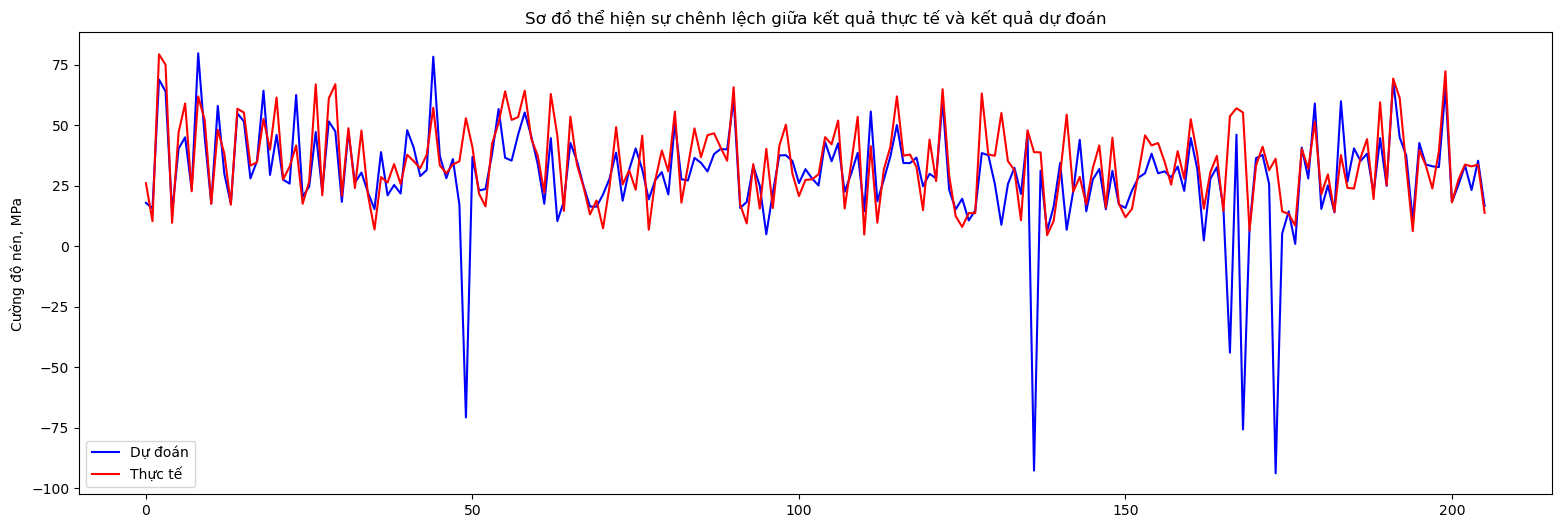

In [277]:
plt.figure(figsize=(19,6))
plt.plot(y_pred, color='blue', label='Dự đoán')
plt.plot(y_test, color='red', label='Thực tế')
plt.title('Sơ đồ thể hiện sự chênh lệch giữa kết quả thực tế và kết quả dự đoán')
plt.ylabel('Cường độ nén, MPa')
plt.legend()
plt.show()

In [278]:
print(w)

[[ 3.40247770e+01]
 [ 2.44086577e+00]
 [ 1.81693673e-01]
 [-7.39141342e-01]
 [ 1.20991228e-03]
 [-1.09976544e+00]
 [ 6.59544096e-01]
 [-2.77135340e-01]
 [ 6.06528560e-01]
 [-7.28071079e-02]
 [ 1.67331050e+00]
 [ 8.91077311e-02]
 [ 1.27700006e+00]
 [-6.93072723e-01]
 [ 6.43116267e-02]
 [ 5.52288306e-01]
 [-8.94998726e-01]
 [-1.62062357e-01]
 [ 1.56391217e-02]
 [-1.52560320e+00]
 [ 1.58013080e+00]
 [ 8.32440224e-01]
 [ 4.32060266e-01]
 [-3.43206021e-01]
 [-3.83428638e-01]
 [-1.36787940e-01]
 [-9.73784097e-01]
 [ 4.87822309e-01]
 [ 6.27181390e-01]
 [-9.50231984e-01]
 [ 7.16941599e-01]
 [ 8.21648499e-02]
 [-6.48699348e-01]
 [ 5.21794307e-01]
 [-4.24353668e-01]
 [-1.11804320e-01]
 [-1.73659313e-01]
 [-1.97858040e-01]
 [ 4.30219501e-01]
 [ 4.17909224e-01]
 [-8.11537006e-01]
 [-1.64288674e-01]
 [ 6.81535635e-02]
 [ 5.05114919e-03]
 [ 9.84921325e-01]
 [-3.33543119e-01]
 [ 1.71395444e+00]
 [ 4.92871921e-02]
 [-1.37732498e-01]
 [ 2.55831636e-01]
 [ 1.25686505e-01]
 [-5.50649600e-02]
 [ 8.8393209

In [279]:
print(y_pred)

[[ 17.94323961]
 [ 15.6518634 ]
 [ 68.87693186]
 [ 63.97793191]
 [ 14.16936411]
 [ 40.38975382]
 [ 45.00914409]
 [ 23.47537487]
 [ 79.73902149]
 [ 44.94335607]
 [ 17.73121449]
 [ 57.98470045]
 [ 29.97492534]
 [ 17.62419893]
 [ 54.88551429]
 [ 51.59039793]
 [ 28.04763499]
 [ 35.16580217]
 [ 64.27788352]
 [ 29.47260313]
 [ 46.00316217]
 [ 27.54365108]
 [ 25.87906218]
 [ 62.49276377]
 [ 20.40715472]
 [ 24.75331434]
 [ 47.18846422]
 [ 22.68330586]
 [ 51.59039793]
 [ 47.44581216]
 [ 18.36667085]
 [ 47.24685872]
 [ 26.24464245]
 [ 30.46491657]
 [ 22.20257113]
 [ 15.3325834 ]
 [ 38.90745393]
 [ 21.04649143]
 [ 25.3131865 ]
 [ 21.79638305]
 [ 47.97214303]
 [ 40.78881854]
 [ 29.00275101]
 [ 31.48898913]
 [ 78.32775418]
 [ 37.33423867]
 [ 28.12397525]
 [ 36.03552253]
 [ 17.1366378 ]
 [-70.72564692]
 [ 36.90845907]
 [ 23.03389337]
 [ 23.66603198]
 [ 38.07487402]
 [ 56.69854974]
 [ 36.5671314 ]
 [ 35.3910275 ]
 [ 46.2021806 ]
 [ 55.28045683]
 [ 45.52220449]
 [ 33.88480729]
 [ 17.57000695]
 [ 44.67